# Penguin body size: species, islands, and bill shape

Analysis notebook for `writeup.md`. The data are the Palmer Penguins measurements in `data/penguins.csv`
(see `data/README.md` for the source and license).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

## Load and clean

In [2]:
penguins = pd.read_csv(ROOT / "data" / "penguins.csv")
print(penguins.shape)
penguins.isna().sum()

(344, 8)


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [3]:
penguins = penguins.dropna()
print(f"{len(penguins)} penguins remain")

333 penguins remain


In [4]:
print(pd.crosstab(penguins["species"], penguins["island"]))
print()
print(pd.crosstab(penguins["species"], penguins["sex"]))

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0

sex        female  male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


## Species differences in body size

In [5]:
measures = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
summary = penguins.groupby("species")[measures].agg(["count", "mean", "std"]).round(1)
summary

bill_length_mm            bill_depth_mm             \
                   count  mean  std         count  mean  std   
species                                                        
Adelie               146  38.8  2.7           146  18.3  1.2   
Chinstrap             68  48.8  3.3            68  18.4  1.1   
Gentoo               119  47.6  3.1           119  15.0  1.0   

          flipper_length_mm             body_mass_g                 
                      count   mean  std       count    mean    std  
species                                                             
Adelie                  146  190.1  6.5         146  3706.2  458.6  
Chinstrap                68  195.8  7.1          68  3733.1  384.3  
Gentoo                  119  217.2  6.6         119  5092.4  501.5

In [6]:
mass = penguins.groupby("species")["body_mass_g"].mean()
pct = (mass["Gentoo"] - mass["Adelie"]) / mass["Gentoo"] * 100
print(f"Mean body mass: Adelie {mass['Adelie']:.0f} g, Gentoo {mass['Gentoo']:.0f} g")
print(f"Gentoo penguins are {pct:.0f}% heavier than Adelie penguins")

Mean body mass: Adelie 3706 g, Gentoo 5092 g
Gentoo penguins are 27% heavier than Adelie penguins


In [7]:
adelie_mass = penguins.loc[penguins["species"] == "Adelie", "body_mass_g"]
chinstrap_mass = penguins.loc[penguins["species"] == "Chinstrap", "body_mass_g"]
res = stats.ttest_ind(adelie_mass, chinstrap_mass, equal_var=False)
ci = res.confidence_interval(confidence_level=0.95)
print(f"Adelie vs Chinstrap body mass: t = {res.statistic:.2f}, p = {res.pvalue:.2f}")
print(f"95% CI for the difference in means: ({ci.low:.0f}, {ci.high:.0f}) g")

Adelie vs Chinstrap body mass: t = -0.45, p = 0.65
95% CI for the difference in means: (-146, 92) g


## Flipper length: Adelie vs Chinstrap

In [8]:
adelie_fl = penguins.loc[penguins["species"] == "Adelie", "flipper_length_mm"]
chinstrap_fl = penguins.loc[penguins["species"] == "Chinstrap", "flipper_length_mm"]
res = stats.ttest_ind(adelie_fl, chinstrap_fl)
ci = res.confidence_interval(confidence_level=0.95)
diff = adelie_fl.mean() - chinstrap_fl.mean()
print(f"Mean difference (Adelie - Chinstrap): {diff:.1f} mm")
print(f"t({res.df:.0f}) = {res.statistic:.2f}, p = {res.pvalue:.1e}")
print(f"95% CI for the difference: ({ci.low:.1f}, {ci.high:.1f}) mm")

Mean difference (Adelie - Chinstrap): -5.7 mm
t(212) = -5.80, p = 2.4e-08
95% CI for the difference: (-7.7, -3.8) mm


In [9]:
for name, values in [("Adelie", adelie_fl), ("Chinstrap", chinstrap_fl)]:
    w, p = stats.shapiro(values)
    print(f"{name}: Shapiro-Wilk W = {w:.3f}, p = {p:.2f}")

Adelie: Shapiro-Wilk W = 0.993, p = 0.74
Chinstrap: Shapiro-Wilk W = 0.989, p = 0.81


In [10]:
gentoo_fl = penguins.loc[penguins["species"] == "Gentoo", "flipper_length_mm"]
w, p = stats.shapiro(gentoo_fl)
print(f"Gentoo: Shapiro-Wilk W = {w:.3f}, p = {p:.4f}")
u = stats.mannwhitneyu(chinstrap_fl, gentoo_fl, alternative="two-sided")
print(f"Chinstrap vs Gentoo flipper length: Mann-Whitney U = {u.statistic:.0f}, p = {u.pvalue:.1e}")

Gentoo: Shapiro-Wilk W = 0.961, p = 0.0018
Chinstrap vs Gentoo flipper length: Mann-Whitney U = 92, p = 1.1e-28


## Body mass and sex in Adelie penguins

In [11]:
adelie = penguins[penguins["species"] == "Adelie"]
males = adelie.loc[adelie["sex"] == "male", "body_mass_g"]
females = adelie.loc[adelie["sex"] == "female", "body_mass_g"]
res = stats.ttest_ind(males, females, equal_var=False)
ci = res.confidence_interval(confidence_level=0.95)
print(f"Adelie males minus females: {males.mean() - females.mean():.0f} g")
print(f"t = {res.statistic:.2f}, p = {res.pvalue:.1e}")
print(f"95% CI for the difference: ({ci.low:.0f}, {ci.high:.0f}) g")

Adelie males minus females: 675 g
t = 13.13, p = 6.4e-26
95% CI for the difference: (573, 776) g


## Differences among islands

In [12]:
islands = ["Biscoe", "Dream", "Torgersen"]
rows = []
for measure in measures:
    for i, first in enumerate(islands):
        for second in islands[i + 1:]:
            a = adelie.loc[adelie["island"] == first, measure]
            b = adelie.loc[adelie["island"] == second, measure]
            res = stats.ttest_ind(a, b, equal_var=False)
            rows.append({"measure": measure, "islands": f"{first} vs {second}",
                         "difference": a.mean() - b.mean(), "p": res.pvalue})
island_tests = pd.DataFrame(rows)
island_tests.round(3)

,measure,islands,difference,p
0,bill_length_mm,Biscoe vs Dream,0.455,0.367
1,bill_length_mm,Biscoe vs Torgersen,-0.063,0.913
2,bill_length_mm,Dream vs Torgersen,-0.518,0.352
3,bill_depth_mm,Biscoe vs Dream,0.130,0.582
4,bill_depth_mm,Biscoe vs Torgersen,-0.081,0.762
5,bill_depth_mm,Dream vs Torgersen,-0.211,0.400
6,flipper_length_mm,Biscoe vs Dream,-1.132,0.400
7,flipper_length_mm,Biscoe vs Torgersen,-2.736,0.047
8,flipper_length_mm,Dream vs Torgersen,-1.605,0.206
9,body_mass_g,Biscoe vs Dream,8.295,0.931


In [13]:
print(penguins.groupby("island")["body_mass_g"].agg(["count", "mean", "std"]).round(0))
groups = [g["body_mass_g"] for _, g in penguins.groupby("island")]
f, p = stats.f_oneway(*groups)
print(f"One-way ANOVA across islands: F = {f:.1f}, p = {p:.1e}")

           count    mean    std
island                         
Biscoe       163  4719.0  791.0
Dream        123  3719.0  413.0
Torgersen     47  3709.0  452.0
One-way ANOVA across islands: F = 105.1, p = 4.9e-36


## Bill length and bill depth

Pearson r = -0.23, p = 2.5e-05, n = 333


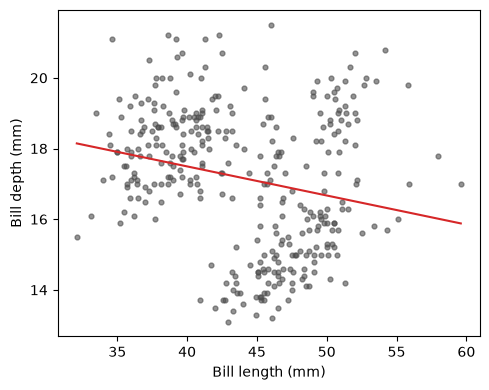

In [14]:
r, p = stats.pearsonr(penguins["bill_length_mm"], penguins["bill_depth_mm"])
print(f"Pearson r = {r:.2f}, p = {p:.1e}, n = {len(penguins)}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"], s=12, alpha=0.6, color="0.3")
slope, intercept = np.polyfit(penguins["bill_length_mm"], penguins["bill_depth_mm"], 1)
xs = np.linspace(penguins["bill_length_mm"].min(), penguins["bill_length_mm"].max(), 50)
ax.plot(xs, intercept + slope * xs, color="C3")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
fig.tight_layout()
fig.savefig(FIGURES / "bill_length_vs_depth.png", dpi=150)
plt.show()

## Figure 1

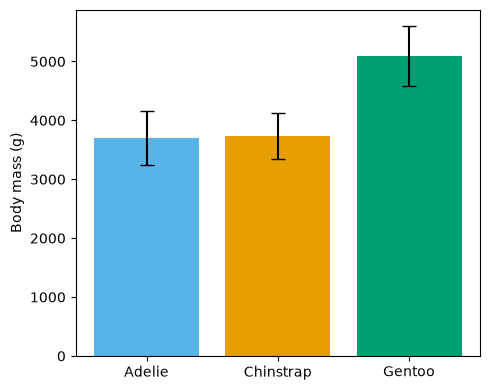

In [15]:
means = penguins.groupby("species")["body_mass_g"].mean()
spread = penguins.groupby("species")["body_mass_g"].std()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(means.index, means.values, yerr=spread.values, capsize=5, color=["#56B4E9", "#E69F00", "#009E73"])
ax.set_ylabel("Body mass (g)")
fig.tight_layout()
fig.savefig(FIGURES / "body_mass_by_species.png", dpi=150)
plt.show()